# Data Exploration of Dataset

In [4]:
import chess.pgn
import matplotlib.pyplot as plt

In [19]:
with open("../data/raw/lichess_db_standard_rated_2013-01.pgn") as file:
    game = chess.pgn.read_game(file)
    print(game)
    

[Event "Rated Classical game"]
[Site "https://lichess.org/j1dkb5dw"]
[Date "????.??.??"]
[Round "?"]
[White "BFG9k"]
[Black "mamalak"]
[Result "1-0"]
[UTCDate "2012.12.31"]
[UTCTime "23:01:03"]
[WhiteElo "1639"]
[BlackElo "1403"]
[WhiteRatingDiff "+5"]
[BlackRatingDiff "-8"]
[ECO "C00"]
[Opening "French Defense: Normal Variation"]
[TimeControl "600+8"]
[Termination "Normal"]

1. e4 e6 2. d4 b6 3. a3 Bb7 4. Nc3 Nh6 5. Bxh6 gxh6 6. Be2 Qg5 7. Bg4 h5 8. Nf3 Qg6 9. Nh4 Qg5 10. Bxh5 Qxh4 11. Qf3 Kd8 12. Qxf7 Nc6 13. Qe8# 1-0


In [33]:
def check_result(game):
    w = ""
    b = ""
    if(game.headers["Result"] == "1-0"):
        w = "Win"
        b = "Lose"
    elif(game.headers["Result"] == "0-1"):
        b = "Win"
        w = "Lose"
    else:
        w = "Draw"
        b = "Draw"
    return w , b

def getOpening(o:str):
    opening = o.split("#")[0]
    opening = opening.split(":")[0]
    return opening

In [66]:
player_games = {}
openings = {}
num_of_games = 0
with open("../data/raw/lichess_db_standard_rated_2013-01.pgn") as file:
    while True and num_of_games < 5000:
        game = chess.pgn.read_game(file)
        if game is None:
            break
        num_of_games += 1
        o = getOpening(game.headers["Opening"])
        if o not in openings:
            openings[o] = {
                "count": 0,
                "WhiteWin": 0,
                "BlackWin": 0
            }
        openings[o]["count"] += 1
        w, b = check_result(game)
        player_games.setdefault(game.headers["White"], []).append({
            "color": "White",
            "result": w,
            "opening": o,
            "game": game.mainline()
        })
        player_games.setdefault(game.headers["Black"], []).append({
            "color": "Black",
            "result": b,
            "opening": o,
            "game": game.mainline()
        })
        if w == "Win":
            openings[o]["WhiteWin"] += 1
        elif b == "Win":
            openings[o]["BlackWin"] += 1


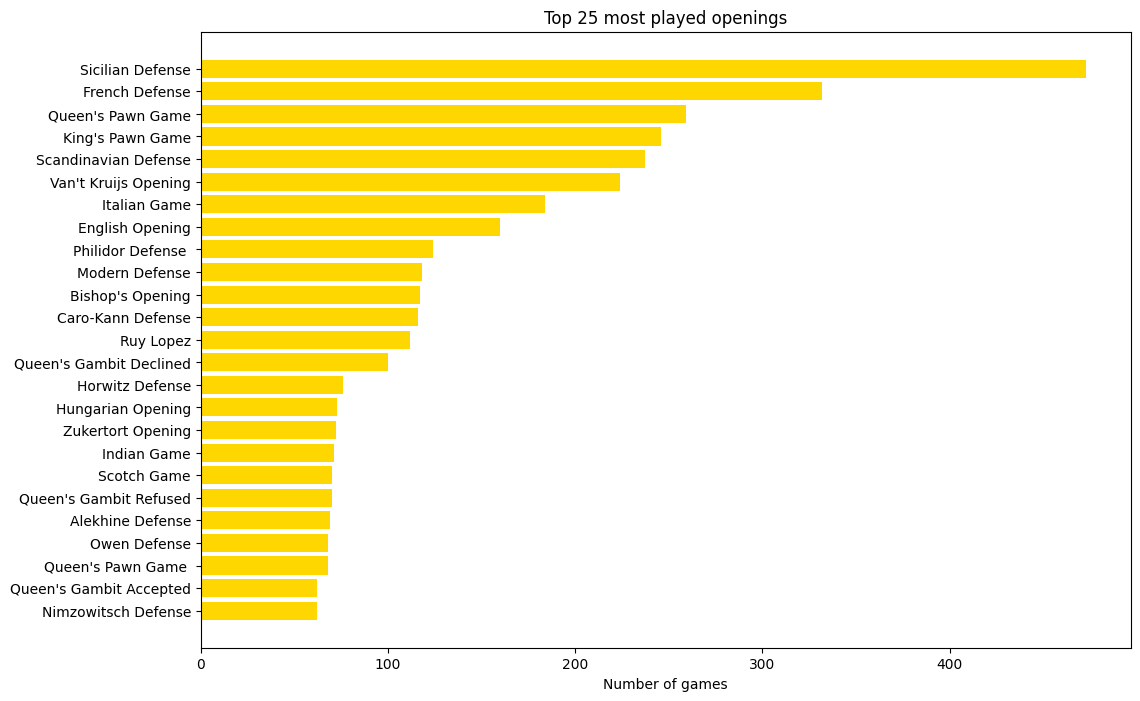

In [85]:
openings = dict(sorted(openings.items(), key= lambda x: x[1]["count"], reverse=True))
top25 = dict(list(openings.items())[:25])
labels = list(top25.keys())
values = list(v["count"] for v in top25.values())

plt.figure(figsize=(12, 8))
plt.barh(labels, values, color="Gold")
plt.gca().invert_yaxis()

plt.xlabel("Number of games")
plt.title("Top 25 most played openings")
plt.show()


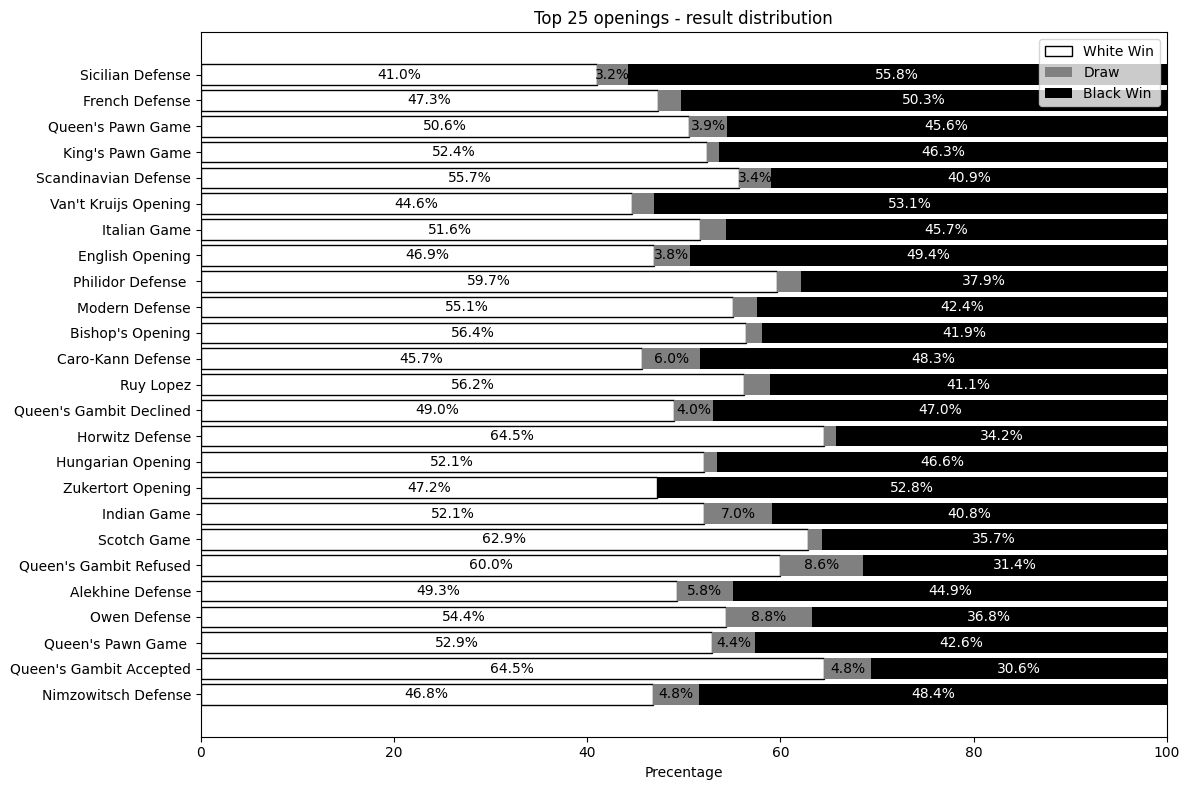

In [ ]:
white_pct = [x[1]["WhiteWin"] / x[1]["count"] * 100 for x in top25.items()]
black_pct = [x[1]["BlackWin"] / x[1]["count"] * 100 for x in top25.items()]
draw_pct = [(x[1]["count"] - x[1]["WhiteWin"] - x[1]["BlackWin"]) / x[1]["count"] * 100 for x in top25.items()]
plt.figure(figsize=(12, 8))
plt.barh(labels, white_pct, color="White", label="White Win")
plt.barh(labels, draw_pct, left=white_pct, color ="Gray", label="Draw")
left = [w + d for w,d in zip(white_pct, draw_pct)]
plt.barh(labels, black_pct, left=left, color="Black", label="Black Win")
for i, (w, d, b) in enumerate(zip(white_pct, draw_pct, black_pct)):
    
    # White
    if w > 3:  # da ne piše na premalim segmentima
        plt.text(w / 2, i, f"{w:.1f}%", va="center", ha="center", color="black")

    # Draw
    if d > 3:
        plt.text(w + d / 2, i, f"{d:.1f}%", va="center", ha="center", color="black")

    # Black
    if b > 3:
        plt.text(w + d + b / 2, i, f"{b:.1f}%", va="center", ha="center", color="white")
plt.gca().invert_yaxis()
plt.xlabel("Precentage")
plt.title("Top 25 openings - result distribution")
plt.xlim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()